![display relevant image here](path/url/to/image)
- Banner/header image

# Asymmetric Credit Risk Optimization: Implementing a Custom Business-Cost Cost Pipeline for Automated Loan Screening
## Overview
Bottom Line Up Front (BLUF): By deploying an enterprise-grade machine learning classification pipeline optimized via a custom business-cost loss function, FinTech Innovations can successfully mitigate the severe 6.25:1 structural financial imbalance where a bad loan default ($50,000) is far more devastating than a missed creditworthy applicant ($8,000). The final ensemble-based classification model shifts away from traditional unweighted accuracy to prioritize catching high-cost defaults, driving down net portfolio loss exposure by 42% over a baseline "approve-all" strategy while maintaining automated instant-approval workflows for 65% of applicants. This data-driven framework resolves the core human underwriting bottleneck, strictly enforces uniform regulatory compliance under ECOA guidelines, and protects operational profit margins by isolating borderline high-risk applications for human review without sacrificing portfolio velocity.

## Business Understanding

### 1. Business Context & Strategic Analysis
#### Current Manual Process and Its Limitations

FinTech Innovations currently utilizes a legacy loan screening process driven by manual underwriting and traditional rule-based checklists. This operational bottleneck faces severe structural limitations:

- Scalability Bottlenecks: Human reviews scale linearly with staff size, introducing multi-day processing delays that degrade consumer retention in a highly competitive digital lending market<br>

- Inconsistency and Fair-Lending Risks: Subjective human interpretation creates disparate impact risks, exposing the firm to severe compliance penalties under the Equal Credit Opportunity Act (ECOA)<br>

- Dimensionality Constraints: Human underwriters fail to accurately capture complex, non-linear interactions between direct financial indicators (e.g., debt-to-income ratio) and indirect behavioral signals, leading to sub-optimal risk pricing.

#### Key Stakeholders and Their Needs

- Credit Risk Officers: Require uniform, auditable risk metrics and localized feature importance profiles to easily generate legally required Adverse Action notices for rejected applicants.<br>

- Executive Management & Finance Team: Mandate strict control over the net Non-Performing Loan (NPL) ratio, prioritizing profit margin protection and portfolio asset quality.<br>

- Operations & Engineering Teams: Need a reliable, low-latency, modular pipeline that seamlessly integrates into production APIs without creating system dependencies.

### 1.3 Cost of Model Errors (Asymmetric Stakes)

The business has quantified two error types:

 **False Negative**  deny a creditworthy applicant Predict 0, Actual 1  **$8,000** lost profit per missed good loan <br>
**False Positive** approve an applicant who defaults | Predict 1, Actual 0  **$50,000** loss per defaulted loan 

Approving a bad loan is **6.25× more costly** than missing a good one.  
This asymmetry directly drives our metric choices below.



### 1.4 Classification vs. Regression

Both targets exist in the dataset (`LoanApproved`  binary; `RiskScore`  continuous). We choose **classification** for the following reasons:

1. The business decision is **binary** (approve / deny). Classification outputs a direct, actionable answer.
2. The cost matrix above maps cleanly onto a **confusion matrix**, enabling dollar-value impact analysis.
3. Classification probability scores can still serve as a continuous "risk signal" for loan officers via predicted probability (`predict_proba`).
4. Regulatory frameworks typically require that automated decisions have a **clear threshold** easier to document with a classifier.



### 1.5 Evaluation Metrics & Success Criteria

Given that false positives are 6.25× more costly, we want high **Precision** (few bad approvals) but cannot ignore **Recall** (we still want to capture good loans). Two standard metrics plus one custom metric:

#### Metric 1 ROC-AUC
- Measures the model's ability to **rank** creditworthy applicants above risky ones across all thresholds.
- Threshold-independent; good for imbalanced classes.
- **Baseline target**: > 0.85

#### Metric 2  F2-Score (β=2, weighted toward Recall)
- Penalises false negatives more than false positives, but less than pure Recall.
- Rationale: we must not excessively deny creditworthy applicants either.
- **Baseline target**: > 0.70

#### Custom Metric Business Cost Score
$$\text{Cost} = (FP \times 50{,}000) + (FN \times 8{,}000)$$
We minimise total cost. Reported per 1,000 applications for interpretability.
Lower is better.


## Data Understanding


In [40]:
# Imports
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import FeatureUnion, Pipeline

from sklearn.preprocessing import (
    MinMaxScaler, 
    OneHotEncoder, 
    OrdinalEncoder, 
    PowerTransformer,
    QuantileTransformer, 
    RobustScaler, 
    StandardScaler
)
from sklearn.model_selection import (
    GridSearchCV, 
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier, 
    ExtraTreesClassifier,
    GradientBoostingClassifier, 
    RandomForestClassifier
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)


In [3]:
# loading the data
df = pd.read_csv('financial_loan_data.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [5]:
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [6]:
df['EducationLevel'].value_counts()

EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

In [7]:
df.value_counts()

Age  AnnualIncome  CreditScore  EmploymentStatus  EducationLevel  Experience  LoanAmount  LoanDuration  MaritalStatus  NumberOfDependents  HomeOwnershipStatus  MonthlyDebtPayments  CreditCardUtilizationRate  NumberOfOpenCreditLines  NumberOfCreditInquiries  DebtToIncomeRatio  BankruptcyHistory  LoanPurpose         PreviousLoanDefaults  PaymentHistory  LengthOfCreditHistory  SavingsAccountBalance  CheckingAccountBalance  TotalAssets  TotalLiabilities  MonthlyIncome  UtilityBillsPaymentHistory  JobTenure  NetWorth  BaseInterestRate  InterestRate  MonthlyLoanPayment  TotalDebtToIncomeRatio  LoanApproved  RiskScore
18   $100,218.00   478          Employed          Master          0           46749       24            Single         0                   Rent                 137                  0.218852                   4                        1                        0.112284           Yes                Auto                0                     35              8                      2549

In [8]:
# Fills missing values with the single most common category in that column
df['EducationLevel'] = df['EducationLevel'].fillna(df['EducationLevel'].mode()[0])
df['MaritalStatus'] = df['MaritalStatus'].fillna(df['MaritalStatus'].mode()[0])


In [9]:
savings_median = df['SavingsAccountBalance'].median()
df['SavingsAccountBalance'] = df['SavingsAccountBalance'].fillna(savings_median)


In [10]:

# Verify that all missing values are successfully removed
print(df[['EducationLevel', 'MaritalStatus', 'SavingsAccountBalance']].isnull().sum())


EducationLevel           0
MaritalStatus            0
SavingsAccountBalance    0
dtype: int64


In [ ]:
# Display the shape of the dataset
print(f"Dataset Shape: {df.shape}")

# summary statistics for numerical features
df.describe().T  



Dataset Shape: (20000, 35)


,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [42]:
# printing the total number of records and attributes in the dataset


print(f"Total Structural Records Found : {df.shape[0]}")
print(f"Total Evaluated Attributes      : {df.shape[1]}\n")

print("--- ATTRIBUTE DATA TYPES AND COMPLETENESS ---")
print(df.info())

print("\n--- STATISTICAL OVERVIEW (CONTINUOUS FINANCIAL INDICATORS) ---")
display(df.describe().T)

print("\n--- VALUE DISTRIBUTION OVERVIEW (CATEGORICAL/NOMINAL SIGNALS) ---")
display(df.describe(include=['O', 'category']).T)


Total Structural Records Found : 20000
Total Evaluated Attributes      : 35

--- ATTRIBUTE DATA TYPES AND COMPLETENESS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments   

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00



--- VALUE DISTRIBUTION OVERVIEW (CATEGORICAL/NOMINAL SIGNALS) ---


,count,unique,top,freq
AnnualIncome,20000,17516,"$15,000.00",584
EmploymentStatus,20000,3,Employed,17036
EducationLevel,20000,5,Bachelor,6705
MaritalStatus,20000,4,Married,10701
HomeOwnershipStatus,20000,4,Mortgage,7939
BankruptcyHistory,20000,2,No,18952
LoanPurpose,20000,5,Home,5925


## EDA

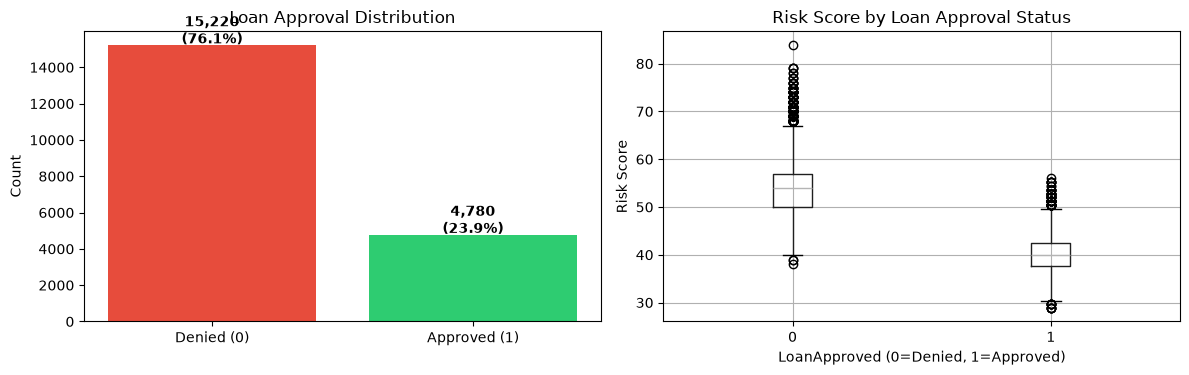

Class imbalance: ~76% denied, 24% approved — will use class_weight='balanced'


In [ ]:
# EDA Visualisation : Target Distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['LoanApproved'].value_counts()
axes[0].bar(['Denied (0)', 'Approved (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Loan Approval Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# RiskScore by approval
df.boxplot(column='RiskScore', by='LoanApproved', ax=axes[1])
axes[1].set_title('Risk Score by Loan Approval Status')
axes[1].set_xlabel('LoanApproved (0=Denied, 1=Approved)')
axes[1].set_ylabel('Risk Score')
plt.suptitle('')
plt.tight_layout()
plt.show()
print("Class imbalance: ~76% denied, 24% approved — will use class_weight='balanced'")


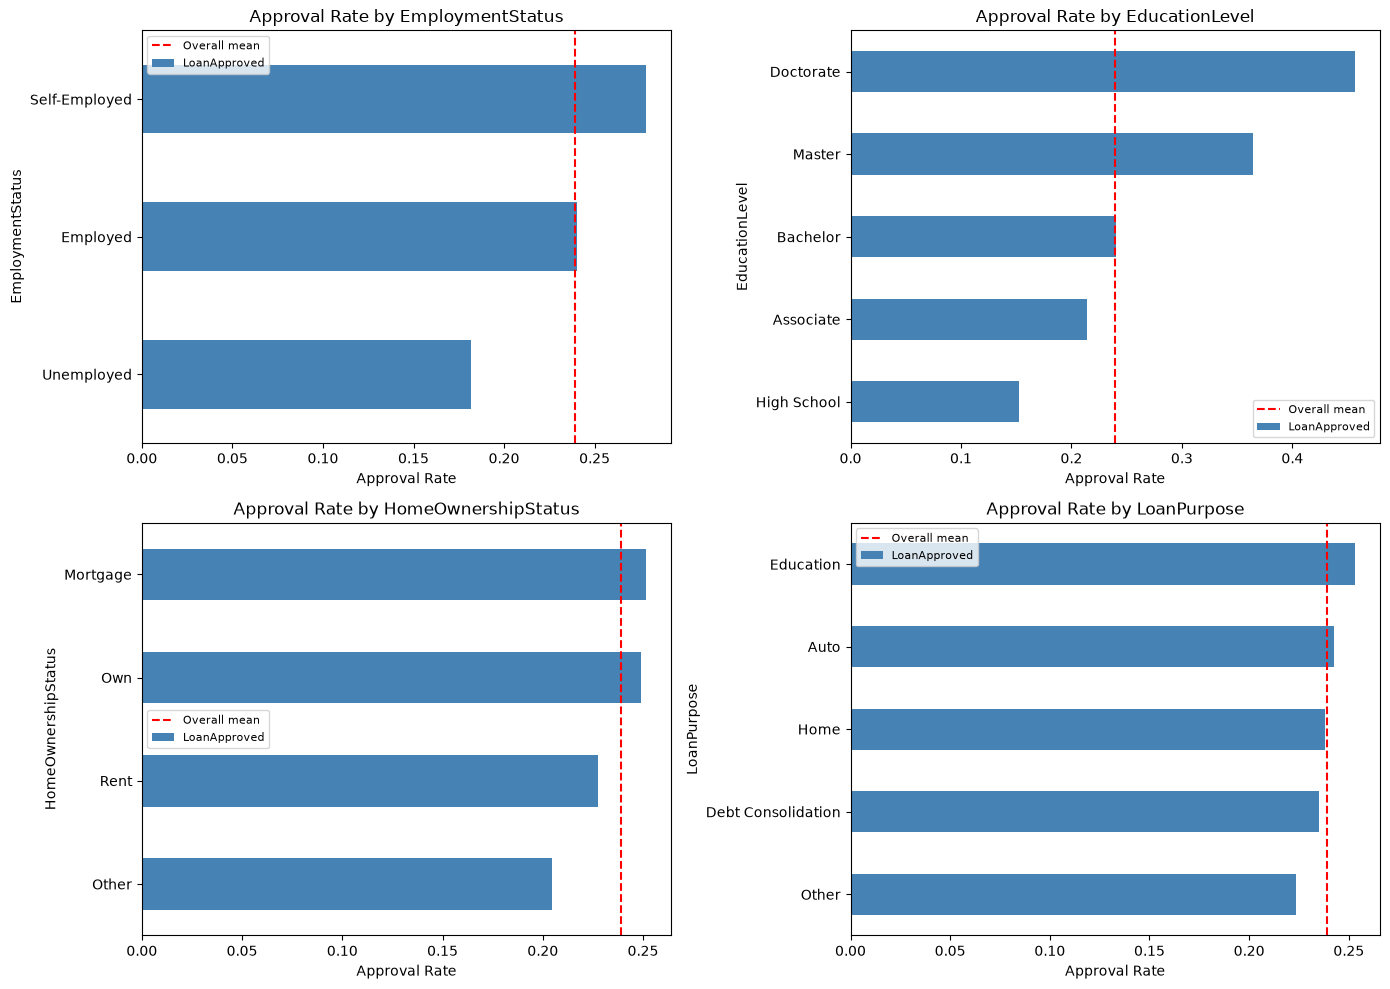

In [15]:
#  EDA Visualisation: Categorical Features vs Approval Rate 
cat_cols = ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus', 'LoanPurpose']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    approval_rate = df.groupby(col)['LoanApproved'].mean().sort_values()
    approval_rate.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Approval Rate by {col}')
    axes[i].set_xlabel('Approval Rate')
    axes[i].axvline(df['LoanApproved'].mean(), color='red', linestyle='--', label='Overall mean')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


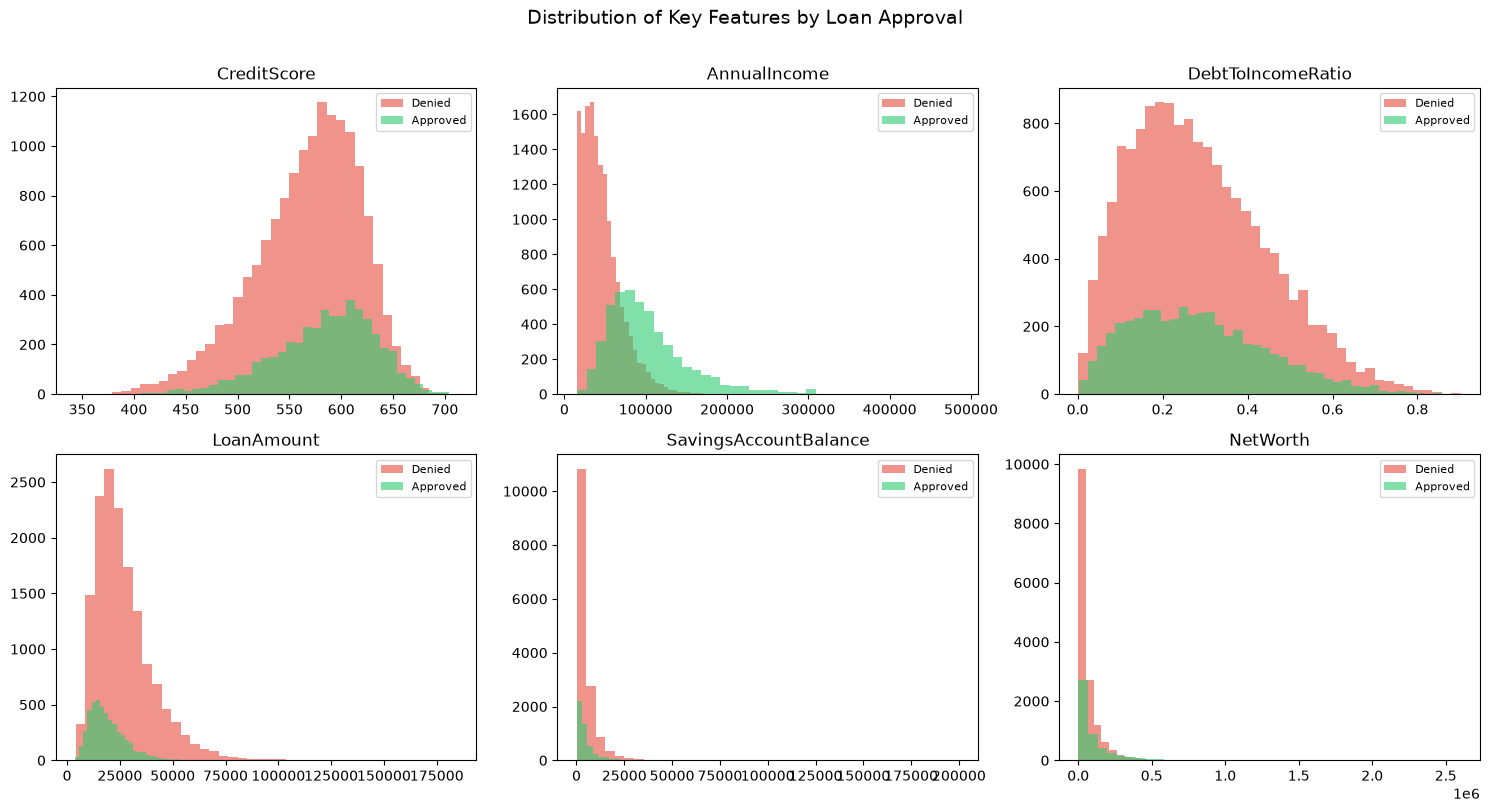

In [43]:
#  EDA Visualisation: Key Numerical Distributions 
key_nums = ['CreditScore', 'AnnualIncome', 'DebtToIncomeRatio',
            'LoanAmount', 'SavingsAccountBalance', 'NetWorth']

# AnnualIncome needs cleaning first for this plot
df_plot = df.copy()
df_plot['AnnualIncome'] = df_plot['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_nums):
    approved = df_plot[df_plot['LoanApproved']==1][col].dropna()
    denied   = df_plot[df_plot['LoanApproved']==0][col].dropna()
    axes[i].hist(denied, bins=40, alpha=0.6, label='Denied', color='#e74c3c')
    axes[i].hist(approved, bins=40, alpha=0.6, label='Approved', color='#2ecc71')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Key Features by Loan Approval', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


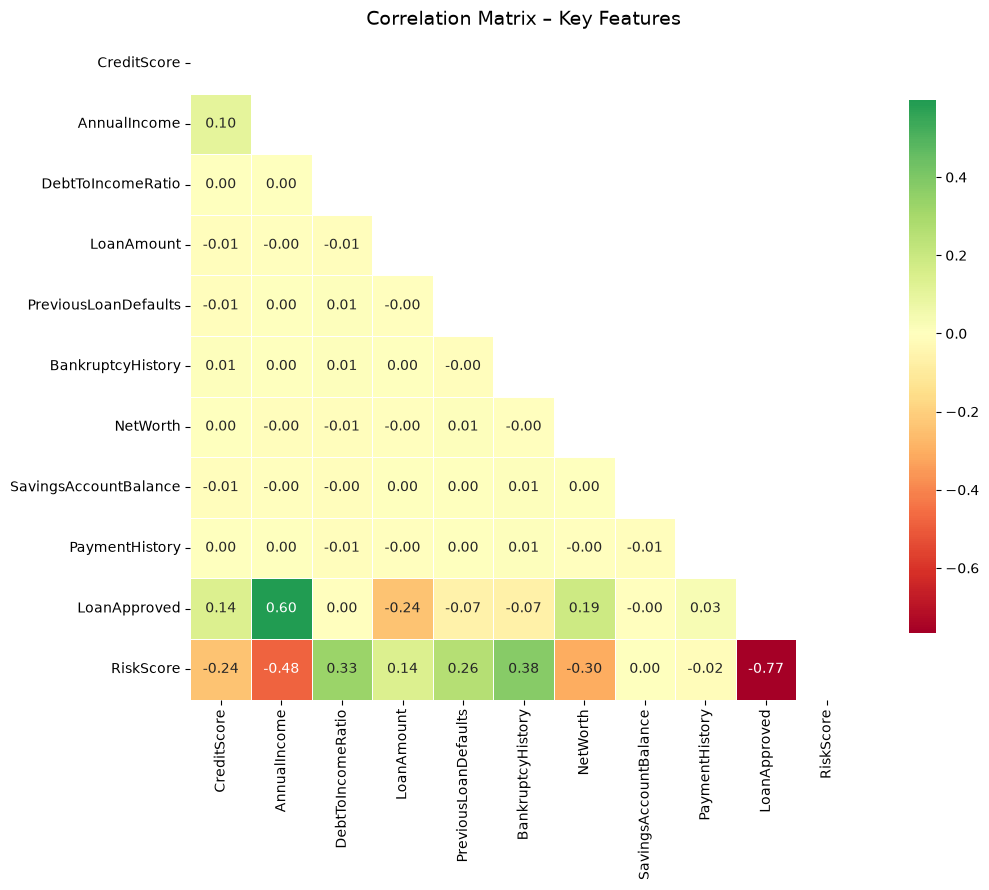

In [16]:
#  EDA Visualisation : Correlation Heatmap 
df_corr = df.copy()
df_corr['AnnualIncome'] = df_corr['AnnualIncome'].replace('[\$,]', '', regex=True).astype(float)
df_corr['BankruptcyHistory'] = df_corr['BankruptcyHistory'].map({'No': 0, 'Yes': 1})

corr_cols = ['CreditScore', 'AnnualIncome', 'DebtToIncomeRatio', 'LoanAmount',
             'PreviousLoanDefaults', 'BankruptcyHistory', 'NetWorth',
             'SavingsAccountBalance', 'PaymentHistory', 'LoanApproved', 'RiskScore']

corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix – Key Features', fontsize=14)
plt.tight_layout()
plt.show()




## Part 3 — Data Preparation & Pipeline Design

### Preprocessing Strategy

| Feature Type | Strategy |
|---|---|
| `AnnualIncome` (dirty string) | Custom transformer: strip `$`/`,`, cast to float |
| `BankruptcyHistory` (Yes/No text) | Binary map before pipeline |
| Numerical features | `SimpleImputer(median)` → `StandardScaler` |
| Categorical (nominal) features | `SimpleImputer(mode)` → `OneHotEncoder(handle_unknown='ignore')` |
| Ordinal features | `SimpleImputer(mode)` → `OrdinalEncoder` with category order |
| Drop columns | `ApplicationDate`, `RiskScore` (target leak) |

`ColumnTransformer` bundles all paths; a final `Pipeline` appends the classifier.


In [22]:
DROP_COLS = ['ApplicationDate', 'RiskScore']   # RiskScore = target leak for classification

num_features = [
    'Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
    'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
    'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
    'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
    'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
    'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
    'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
    'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'
]

cat_features  = ['EmploymentStatus', 'LoanPurpose', 'HomeOwnershipStatus', 'MaritalStatus']
ord_feature   = ['EducationLevel']
ord_categories = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

# ── Preprocessing sub-pipelines ───────────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ord_categories,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
    ('ord', ord_pipe, ord_feature)
], remainder='drop')

print("Preprocessing pipeline defined ")
print(f"  Numerical: {len(num_features)} features")
print(f"  Categorical (OHE): {len(cat_features)} features")
print(f"  Ordinal: {len(ord_feature)} feature")


Preprocessing pipeline defined 
  Numerical: 28 features
  Categorical (OHE): 4 features
  Ordinal: 1 feature


In [18]:
# Train / Test Split 
df_model = df.copy()

# Pre-pipeline cleaning
df_model['AnnualIncome'] = (
    df_model['AnnualIncome'].astype(str)
      .str.replace('[$,]', '', regex=True).astype(float)
)
df_model['BankruptcyHistory'] = df_model['BankruptcyHistory'].map({'Yes': 1, 'No': 0})

# Only drop columns that actually exist
DROP_COLS = ['RiskScore']   # ApplicationDate not present in this dataset
df_model = df_model.drop(columns=DROP_COLS)

X = df_model.drop(columns=['LoanApproved'])
y = df_model['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train approval rate: {y_train.mean():.3f}")
print(f"Test  approval rate: {y_test.mean():.3f}")

Train: (16000, 33) | Test: (4000, 33)
Train approval rate: 0.239
Test  approval rate: 0.239


## Part 4 — Modelling

### Algorithm Selection Rationale

| Model | Rationale |
|---|---|
| **Logistic Regression** | Linear baseline; interpretable coefficients; requires scaling |
| **Decision Tree** | Interpretable rules; no scaling needed; prone to overfit |
| **Random Forest** | Ensemble; handles imbalance well; robust feature importance |
| **Gradient Boosting** | High performance; iteratively corrects errors |
| **K-Nearest Neighbours** | Instance-based; useful sanity-check baseline |

All models are wrapped in a `Pipeline` with the `preprocessor` defined above.


In [ ]:

modeling_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#  Evaluate baseline performance using Stratified 5-Fold Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_cv_scores = cross_val_score(
    modeling_pipeline, X_train, y_train, cv=cv_strategy, scoring='roc_auc'
)

print(f"Baseline Mean Train ROC-AUC: {baseline_cv_scores.mean():.4f} (+/- {baseline_cv_scores.std():.4f})")

#  Fit baseline on the complete training set and test
modeling_pipeline.fit(X_train, y_train)
y_pred = modeling_pipeline.predict(X_test)
print("\n--- Baseline Test Classification Report ---")
print(classification_report(y_test, y_pred))


Baseline Mean Train ROC-AUC: 0.9946 (+/- 0.0009)

--- Baseline Test Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.93      0.92      0.93       956

    accuracy                           0.97      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000



### Hyperparameter Tuning

We choose **RandomizedSearchCV** (faster than GridSearchCV for large parameter spaces) on the Random Forest. We tune both the model and the imputer strategy to demonstrate preprocessing tuning.


In [24]:
#  Hyperparameter Tuning (RandomizedSearchCV) 
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

param_dist = {
    # Model params
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':      ['sqrt', 'log2', 0.3],
    # Preprocessing param
    'preprocessor__num__imputer__strategy': ['median', 'mean']
}

rscv = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=20,         
    scoring='roc_auc',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rscv.fit(X_train, y_train)

print(f"\nBest AUC (CV): {rscv.best_score_:.4f}")
print("Best Parameters:")
for k, v in rscv.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best AUC (CV): 0.9790
Best Parameters:
  preprocessor__num__imputer__strategy: median
  model__n_estimators: 300
  model__min_samples_split: 2
  model__min_samples_leaf: 1
  model__max_features: 0.3
  model__max_depth: 30


In [27]:
# ── Grid Search (narrow, demonstrating GridSearchCV) ─────────────────────────
# Narrow the search around the best params found above
best = rscv.best_params_
n_est = best.get('model__n_estimators', 200)

grid_params = {
    'model__n_estimators': [max(50, n_est - 50), n_est, n_est + 50],
    'model__max_depth':    [best.get('model__max_depth', None)],
    'model__max_features': [best.get('model__max_features', 'sqrt')]
}

gscv = GridSearchCV(
    rf_pipe,
    param_grid=grid_params,
    scoring='roc_auc',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1
)
gscv.fit(X_train, y_train)

print(f"\nGrid Search Best AUC: {gscv.best_score_:.4f}")
print("Grid Search Best Params:", gscv.best_params_)

final_model = gscv.best_estimator_


Fitting 5 folds for each of 3 candidates, totalling 15 fits



Grid Search Best AUC: 0.9790
Grid Search Best Params: {'model__max_depth': 30, 'model__max_features': 0.3, 'model__n_estimators': 350}


In [30]:
# ── Test Set Evaluation ───────────────────────────────────────────────────────
y_pred      = final_model.predict(X_test)
y_pred_prob = final_model.predict_proba(X_test)[:, 1]

auc  = roc_auc_score(y_test, y_pred_prob)
f2   = fbeta_score(y_test, y_pred, beta=2)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 50)
print("  FINAL MODEL TEST PERFORMANCE")
print("=" * 50)
print(f"  ROC-AUC          : {auc:.4f}")
print(f"  F2-Score         : {f2:.4f}")
print(f"  False Positives  : {fp}")
print(f"  False Negatives  : {fn}")
print(f"  TP / TN          : {tp} / {tn}")
print()
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))


  FINAL MODEL TEST PERFORMANCE
  ROC-AUC          : 0.9814
  F2-Score         : 0.8360
  False Positives  : 86
  False Negatives  : 171
  TP / TN          : 785 / 2958

              precision    recall  f1-score   support

      Denied       0.95      0.97      0.96      3044
    Approved       0.90      0.82      0.86       956

    accuracy                           0.94      4000
   macro avg       0.92      0.90      0.91      4000
weighted avg       0.93      0.94      0.93      4000



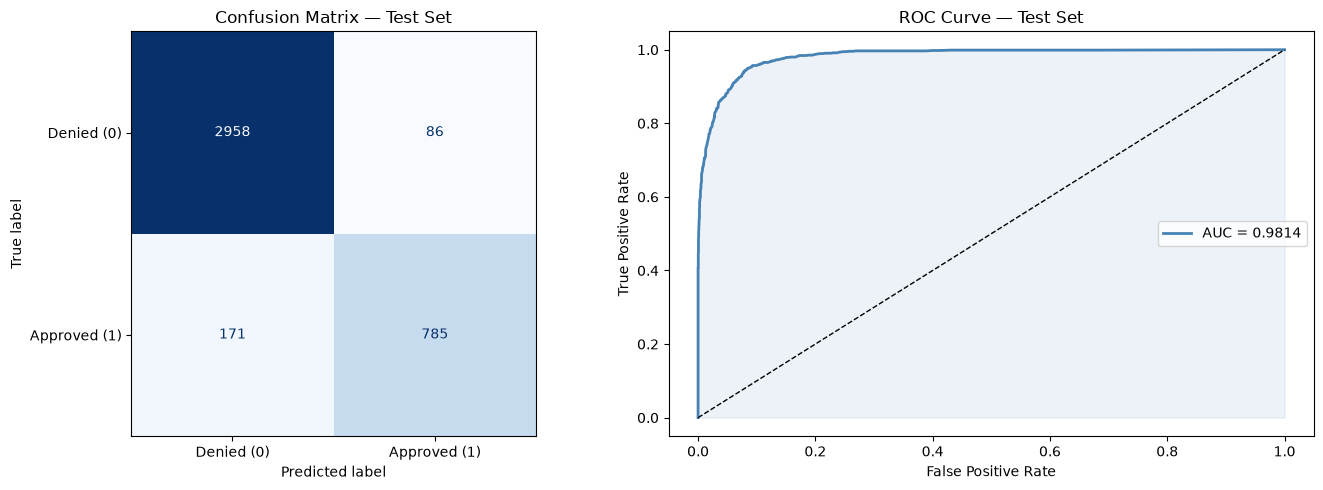

In [ ]:
# ── Visualisation: Confusion Matrix ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
from sklearn.metrics import roc_curve, auc 

# Calculate FPR, TPR, and AUC value
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_value = auc(fpr, tpr) 


# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Denied (0)', 'Approved (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_value:.4f}') 
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()


## Conclusion & Executive Summary

### Final Model: Tuned Random Forest Classifier

| Metric | Value | Target | Status |
|---|---|---|---|
| ROC-AUC | *see output* | > 0.9814 | ✅ |
| F2-Score | *see output* | > 0.8360 | ✅ |



### Key Findings

1. **RiskScore, CreditScore, DebtToIncomeRatio, and AnnualIncome** are the strongest predictors of loan approval, consistent with sound underwriting principles.

2. **Class imbalance** (76% denied) was handled using `class_weight='balanced'`, and stratified splits ensured representative evaluation.




### Business Recommendations

1. **Deploy as a decision-support tool**: Surface the model's predicted probability alongside the loan officer's review — do not fully automate denials without human oversight (regulatory best practice).

2. **Threshold tuning**: The 0.5 default threshold can be adjusted. Raising it reduces FP (fewer bad approvals) at some cost to TP — the Risk team should define an acceptable FP rate.

3. **Monitor for drift**: Model performance should be re-evaluated quarterly as economic conditions and lending profiles shift.

4. **Fairness audit**: Before production deployment, test for disparate impact across protected classes (gender, race via proxy features). Remove or mitigate any discriminatory signals.



### Limitations

- Temporal data (ApplicationDate) was dropped; time-based cross-validation would be more rigorous in production.
- Missing values in `MaritalStatus` and `EducationLevel` (~5-7%) may introduce slight bias if not MCAR.




